In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver # for persistence
load_dotenv()

True

### Persistence

Persistence in Langgraph refers to the ability to SAVE and RESTORE the state of a workflow over time.

SAVE:
So here, not only the values in the final state are saved, but also values in intermediate states when workflow was running, they also get saved.

RESTORE:
Since intermediate states are saved and can be accessed/restored, if a workflow crashes at an intermediate node, we can just access the state from that node and continue working without having to start from scratch. This is fault tolerance.


### Checkpointers in Persistence

The logic of persistence, i.e. saving values in states at intermediate states, is implemented by checkpointers.

Consider the follow workflow: 


In [3]:
class ExampleState(TypedDict):
    pass

In [4]:
def node_1(state: ExampleState):
    pass

def node_2(state: ExampleState):
    pass

def node_3(state: ExampleState):
    pass

def node_4(state: ExampleState):
    pass

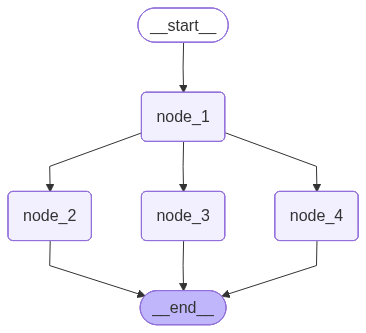

In [6]:
graph = StateGraph(ExampleState)

graph.add_node("node_1", node_1)
graph.add_node("node_2", node_2)
graph.add_node("node_3", node_3)
graph.add_node("node_4", node_4)

graph.add_edge(START, "node_1")
graph.add_edge("node_1", "node_2")
graph.add_edge("node_1", "node_3")
graph.add_edge("node_1", "node_4")
graph.add_edge("node_2", END)
graph.add_edge("node_3", END)
graph.add_edge("node_4", END)

w = graph.compile()
w

The way checkpointers work is: Every superstep of our graph become a checkpoint. (START to node 1 is one superstep, node 1 to node 2 3 4 is another superstep, etc.)

So here, 4 checkpointers are created at 4 horizontal levels of the workflow.

START has a checkpointer which saves the values of initial state.

Then there's another checkpointer at node 1 level which saves values of state after whatever node 1 did and however the state got updated then.

The another checkpointer at next level which saves whatever node 2 3 4 did.

And a final checkpointer which saves values in final state.

### Threads in Persistence

Again, consider it like the left side panel of chatgpt web interface, where various chats are stored of specific conversations and we can resume any one at any time.

When using persistence, a thread_id is created, an every invoke() call uses a certain thread_id.

So you can have thread_id = "build resume" and call invoke() on graph and every thing gets saved with this thread_id, but then you can also have thread_id = "write cover letter" and call invoke() on the same graph and everything gets saved associated with this thread_id, and both can be accessed at any time.

Example:

START --> topic --> gen joke --> gen explanation --> END

In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver # this is a type of checkpointer which saves intermediate and final state to memory
load_dotenv()

True

In [8]:
llm = ChatOpenAI(model="gpt-4.1-nano")

In [9]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [10]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [11]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

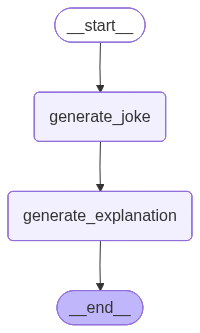

In [13]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [14]:
config1 = {'configurable': {'thread_id': '1'}}
workflow.invoke({'topic': 'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the party?  \nBecause it knew how to "dough" the right moves!',
 'explanation': 'Sure! The joke plays on a pun involving the word "dough," which is the mixture of flour, water, and other ingredients used to make pizza crust, and the phrase "know how to do the right moves." \n\nIn the joke:\n- "Dough" sounds like "do," so when it says the pizza "knew how to dough the right moves," it\'s a humorous way of saying the pizza knew how to "do" or perform the right dance moves at the party.\n- It\'s funny because it attributes human-like qualities to a pizza—suggesting it can dance or move skillfully—by playing on the similarity in sound between "dough" and "do."\n\nOverall, it\'s a pun that combines food terminology with the idea of dancing or performing well at a party.'}

In [15]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the party?  \nBecause it knew how to "dough" the right moves!', 'explanation': 'Sure! The joke plays on a pun involving the word "dough," which is the mixture of flour, water, and other ingredients used to make pizza crust, and the phrase "know how to do the right moves." \n\nIn the joke:\n- "Dough" sounds like "do," so when it says the pizza "knew how to dough the right moves," it\'s a humorous way of saying the pizza knew how to "do" or perform the right dance moves at the party.\n- It\'s funny because it attributes human-like qualities to a pizza—suggesting it can dance or move skillfully—by playing on the similarity in sound between "dough" and "do."\n\nOverall, it\'s a pun that combines food terminology with the idea of dancing or performing well at a party.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14072d-2d5f-67d2-8002-cf9cb3b87ab2'}}, metadata={'source'

In [16]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the party?  \nBecause it knew how to "dough" the right moves!', 'explanation': 'Sure! The joke plays on a pun involving the word "dough," which is the mixture of flour, water, and other ingredients used to make pizza crust, and the phrase "know how to do the right moves." \n\nIn the joke:\n- "Dough" sounds like "do," so when it says the pizza "knew how to dough the right moves," it\'s a humorous way of saying the pizza knew how to "do" or perform the right dance moves at the party.\n- It\'s funny because it attributes human-like qualities to a pizza—suggesting it can dance or move skillfully—by playing on the similarity in sound between "dough" and "do."\n\nOverall, it\'s a pun that combines food terminology with the idea of dancing or performing well at a party.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14072d-2d5f-67d2-8002-cf9cb3b87ab2'}}, metadata={'source

In [17]:
len(list(workflow.get_state_history(config1)))

4

In [23]:
for i in (list(workflow.get_state_history(config1))):
    print(i)
    print('---'*25)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the party?  \nBecause it knew how to "dough" the right moves!', 'explanation': 'Sure! The joke plays on a pun involving the word "dough," which is the mixture of flour, water, and other ingredients used to make pizza crust, and the phrase "know how to do the right moves." \n\nIn the joke:\n- "Dough" sounds like "do," so when it says the pizza "knew how to dough the right moves," it\'s a humorous way of saying the pizza knew how to "do" or perform the right dance moves at the party.\n- It\'s funny because it attributes human-like qualities to a pizza—suggesting it can dance or move skillfully—by playing on the similarity in sound between "dough" and "do."\n\nOverall, it\'s a pun that combines food terminology with the idea of dancing or performing well at a party.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14072d-2d5f-67d2-8002-cf9cb3b87ab2'}}, metadata={'source'

There 4 values here, corresponding to each horizontal level in our graph. 

The last one actually corresponds to START node, and since in the beginning the value of state is empty, it says values = {} and how the next is the START node.

The second last one: at this point, we have the joke as topic/input. So values = {topic: pizza} and next node to run is generate_joke.

3rd last: at this point, we have generated topic and joke, which is in values and next node to run is generate_explanation.

1st value in list: we have everything now, so everyhting is in values now and there's nothing to execute now so it's next=().

In [24]:
config2 = {'configurable': {'thread_id': '2'}}
workflow.invoke({'topic': 'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti go to the party? Because it knew how to tie one on!',
 'explanation': 'This joke plays on a double meaning involving spaghetti and the phrase "tie one on." \n\n- **Spaghetti** is a type of pasta that is long and thin, and it is often tied together or held with a fork, which naturally involves "tying."\n- The phrase **"tie one on"** is an idiomatic expression meaning to drink alcohol excessively or to go out and have a lively, often wild, time at a party.\n\nSo, the joke combines these ideas: the spaghetti "going to the party" because it "knew how to tie one on" humorously suggests that the pasta is capable of both tying itself and partying hard—playing on the literal and figurative meanings of the phrase.'}

In [25]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to the party? Because it knew how to tie one on!', 'explanation': 'This joke plays on a double meaning involving spaghetti and the phrase "tie one on." \n\n- **Spaghetti** is a type of pasta that is long and thin, and it is often tied together or held with a fork, which naturally involves "tying."\n- The phrase **"tie one on"** is an idiomatic expression meaning to drink alcohol excessively or to go out and have a lively, often wild, time at a party.\n\nSo, the joke combines these ideas: the spaghetti "going to the party" because it "knew how to tie one on" humorously suggests that the pasta is capable of both tying itself and partying hard—playing on the literal and figurative meanings of the phrase.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f140743-7a44-6230-8002-6f195f8e8f61'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-25T06

In [32]:
for i in (list(workflow.get_state_history(config2))):
    print(str(i)[:200])
    print('---'*25)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to the party? Because it knew how to tie one on!', 'explanation': 'This joke plays on a double meaning involving spaghetti and
---------------------------------------------------------------------------
StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to the party? Because it knew how to tie one on!'}, next=('generate_explanation',), config={'configurable': {'thread_id': '2',
---------------------------------------------------------------------------
StateSnapshot(values={'topic': 'pasta'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f140743-60ae-6b04-8000-bc0ca07ae854'}}, metadata={'
---------------------------------------------------------------------------
StateSnapshot(values={}, next=('__start__',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f140743-60ab-6b2a-bfff-5cdb1aa1a379'}}, 

In [33]:
for i in (list(workflow.get_state_history(config1))):
    print(str(i)[:200])
    print('---'*25)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the party?  \nBecause it knew how to "dough" the right moves!', 'explanation': 'Sure! The joke plays on a pun involving the wor
---------------------------------------------------------------------------
StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the party?  \nBecause it knew how to "dough" the right moves!'}, next=('generate_explanation',), config={'configurable': {'thre
---------------------------------------------------------------------------
StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14072d-11f4-6420-8000-fabbab1a8817'}}, metadata={'
---------------------------------------------------------------------------
StateSnapshot(values={}, next=('__start__',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14072d-11f0-6c4e-bfff-14b546e743b7'}}, 

This shows that workflow internally has saved information of two different threads, and also it has saved all the intermediate states.

### With persistence we get concepts of:

- Short Term Memory
- Fault Tolerance
- HITL
- Time Travel

### 1. Short Term Memory

Storing past conversations somewhere and resuming conversation from there, more on this in later notebooks.

### 2. Human in the Loop

Waiting for a human's manual approval before continuing, more on this in later notebooks.

### 3. Time Travel

This means we can replay the execution of our workflow. So once the whole workflow has been executed, we can go back to any checkpoint and retry/replay the following states from there. Helps in debugging.

Example:

Let's go back to the state where had the topic as pizza, but joke and explanation hadn't been generated yet, and generate joke and explanation again.

In [34]:
# to get to that state, we needs its checkpoint id
for i in (list(workflow.get_state_history(config1))):
    print(str(i)[:300])
    print('---'*25)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the party?  \nBecause it knew how to "dough" the right moves!', 'explanation': 'Sure! The joke plays on a pun involving the word "dough," which is the mixture of flour, water, and other ingredients used to make pizza crust, and
---------------------------------------------------------------------------
StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the party?  \nBecause it knew how to "dough" the right moves!'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14072d-21c4-659e-8001-b58d15ad191d'}}, metadat
---------------------------------------------------------------------------
StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14072d-11f4-6420-8000-fabbab1a8817'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, cr

We see that every checkpoint has its unique id, and we copy paste the one in second last where we only had the topic, so: 1f14072d-11f4-6420-8000-fabbab1a8817

In [37]:
# now we can access it like
workflow.get_state({'configurable': {'thread_id': '1', 'checkpoint_id': '1f14072d-11f4-6420-8000-fabbab1a8817'}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f14072d-11f4-6420-8000-fabbab1a8817'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-25T06:48:50.413256+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14072d-11f0-6c4e-bfff-14b546e743b7'}}, tasks=(PregelTask(id='05bb7a2d-fe7c-815b-d294-47ef13fb5c7e', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza go to the party?  \nBecause it knew how to "dough" the right moves!'}),), interrupts=())

In [ ]:
# now we want to run the workflow again from this state, so instead of passing a initial_state we can just pass None
workflow.invoke(None, {'configurable': {'thread_id': '1', 'checkpoint_id': '1f14072d-11f4-6420-8000-fabbab1a8817'}})

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the party?  \n\nBecause it was topping the charts!',
 'explanation': 'The joke plays on the double meaning of the phrase "topping the charts." Normally, "topping the charts" is a phrase used in music or entertainment to describe something very popular or at the very top of rankings. In the joke, it\'s a pun because a pizza has toppings (like pepperoni, mushrooms, etc.), and "topping" literally refers to the ingredients placed on the pizza. So, the pizza went to the party because it was "topping the charts," humorously blending the idea of being popular (chart-topping hits) with the literal toppings on a pizza.'}

In [ ]:
# running it again
workflow.invoke(None, {'configurable': {'thread_id': '1', 'checkpoint_id': '1f14072d-11f4-6420-8000-fabbab1a8817'}})

{'topic': 'pizza',
 'joke': 'Why did the pizza lose its temper? Because it was feeling a little *crust*y!',
 'explanation': 'This joke plays on a pun involving the word "crusty." The punchline—"because it was feeling a little *crust*y"—sounds like "rusty," which can describe something old or stiff, but is also related to a pizza\'s crust. The humor comes from imagining a pizza getting angry because its crust is "crusty," turning a culinary term into a playful emotional state. Essentially, it\'s a funny way of personifying a pizza and linking its physical characteristic (the crust) to a mood or attitude.'}

In [42]:
for i in (list(workflow.get_state_history(config1))):
    print(str(i)[:300])
    print('---'*25)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza lose its temper? Because it was feeling a little *crust*y!', 'explanation': 'This joke plays on a pun involving the word "crusty." The punchline—"because it was feeling a little *crust*y"—sounds like "rusty," which can describe somet
---------------------------------------------------------------------------
StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza lose its temper? Because it was feeling a little *crust*y!'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f141005-34fe-63ea-8002-e791c7484468'}}, metadata={'sourc
---------------------------------------------------------------------------
StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f141005-2632-688e-8001-1909a3892a4b'}}, metadata={'source': 'fork', 'step': 1, 'parents': {}}, cr

#### Updating state

We can also go back to a certain state and update values in there and run workflow again from there.

This sort of internally creates a branching between 2 nodes.

Ex: changing topic from pizza to samosa

In [46]:
workflow.update_state({'configurable': {'thread_id': '1', 'checkpoint_id': '1f14072d-11f4-6420-8000-fabbab1a8817', 'checkpoint_ns': ''}}, {'topic': 'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f141013-395b-6948-8001-b9bf70a20aab'}}

In [47]:
for i in (list(workflow.get_state_history(config1))):
    print(str(i)[:300])
    print('---'*25)

StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f141013-395b-6948-8001-b9bf70a20aab'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-04-25T23:48:04.141890+00:00', parent
---------------------------------------------------------------------------
StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f141011-228b-60e4-8001-cbea48183319'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-04-25T23:47:08.062520+00:00', parent
---------------------------------------------------------------------------
StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza lose its temper? Because it was feeling a little *crust*y!', 'explanation': 'This joke plays on a pun involving the word "crusty." The punchline—"because it was feeling a little *

I ran this twice by mistake but we see samosa on top 2 so topic got updated in the latest 2 states.

In [ ]:
# running it from that checkpoint by giving its new checkpoint id
workflow.invoke(None, {'configurable': {'thread_id': '1', 'checkpoint_id': '1f141013-395b-6948-8001-b9bf70a20aab'}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to therapy?\n\nBecause it had too many layers to peel back!',
 'explanation': 'This joke is a playful pun that combines the physical qualities of a samosa with a common metaphor for emotional or psychological complexity. Samosas are savory pastries that typically have multiple layers of crispy dough and filling, symbolizing their layered structure. \n\nThe humor comes from treating these layers as if they represent emotional or personal issues that need to be uncovered or understood—similar to how someone might go to therapy to peel back hidden feelings or problems. The phrase "too many layers to peel back" cleverly ties the literal layers of the samosa with the metaphorical idea of emotional complexity, making the joke amusing through wordplay.'}

In [50]:
for i in (list(workflow.get_state_history(config1))):
    print(str(i)[:300])
    print('---'*25)

StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to therapy?\n\nBecause it had too many layers to peel back!', 'explanation': 'This joke is a playful pun that combines the physical qualities of a samosa with a common metaphor for emotional or psychological complexity. Samosas 
---------------------------------------------------------------------------
StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to therapy?\n\nBecause it had too many layers to peel back!'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f141019-9d5a-6240-8002-7d625cd77825'}}, metadata={
---------------------------------------------------------------------------
StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the party alone?  \n\nBecause it was tired of being *dough*-nuted!', 'explanation': 'This joke plays on puns involving words related to pizza and donuts. The punchline "beca

### 4. Fault Tolerance

If a crash happens from any certain node, we can continue workflow from there instead of starting from scratch.

Example: In a simple workflow with START -> step 1 -> step 2 -> step 3 -> END, we will simulate a crash on step 2 node by adding 30 sec wait time there and I will interrupt cell there to "crash workflow". And then we will resume the workflow from that node.

In [1]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [2]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

In [3]:

# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(30)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("Step 3 executed")
    return {"step3": "done"}

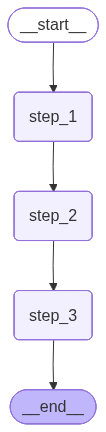

In [4]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [5]:
# run this cell and stop cell execution which is just on the left (in vs code atleast)
try:
    print("Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("Kernel manually interrupted (crash simulated).")

Running graph: Please manually interrupt during Step 2...
Step 1 executed
Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
Kernel manually interrupted (crash simulated).


In [6]:
graph.get_state({"configurable": {"thread_id": 'thread-1'}})

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f141061-4e5d-685c-8001-1034b0b3c04b'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-04-26T00:23:00.141261+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f141061-4e5c-6132-8000-4586aa13f8ea'}}, tasks=(PregelTask(id='ff25c52b-c979-7439-b980-37bb44dc3e1d', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

We see graph only ran till step1 which is done, and there's nothing after that. In real life debugging scenarios, this lets us know that it crashed at node step2.

In [63]:
# same we see here in the history
for i in (list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))):
    print(str(i)[:200])
    print('---'*25)

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f141031-59f0-651e-8001-4ef0fdf6799
---------------------------------------------------------------------------
StateSnapshot(values={'input': 'start'}, next=('step_1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f141031-59ee-63fe-8000-8763aa6e5fa1'}}, metadata={'
---------------------------------------------------------------------------
StateSnapshot(values={}, next=('__start__',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f141031-59ea-6b46-bfff-df74998ddbcd'}}, metadata={'source': 'inp
---------------------------------------------------------------------------


In [7]:
# 6. Re-run to show fault-tolerant resume by giving None, also dont interrupt this time and let it complete in 30 sec
print("\nRe-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\nFinal State:", final_state)


Re-running the graph to demonstrate fault tolerance...
Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
Step 3 executed

Final State: {'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}


We see how step1 done doesn't get printed any more, because it is just resuming and will continue from node step 2.

In [8]:
for i in (list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))):
    print(str(i)[:300])
    print('---'*25)

StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f141062-f166-6f70-8003-c243654af1ce'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='20
---------------------------------------------------------------------------
StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f141062-f164-63b0-8002-2f0dfa93b80e'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-26
---------------------------------------------------------------------------
StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f141061-4e5d-685c-8001-1034b0b3c04b'}}, metadata={'source': 'loop', 'step': 1, '